# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_rate = df.isnull().mean()
print("Tỉ lệ missing của các côt:", missing_rate)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = [
    "alive",
    "who",
    "adult_male",
    "class",
    "deck",
    "embark_town"
]      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

Tỉ lệ missing của các côt: survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Vì `alive` chứa dữ liệu tương ứng, hay ánh xạ hoàn toàn với cột `survived`; hay nói cách khác là chỉ thay đổi cách biểu diễn. Trong đó, `survived` là có miền giá trị {1, 0} hay {True, False}, còn `alive` có miền giá trị {"yes", "no"}.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
n_rows, n_cols = df.shape
target_col = "survived"
print("Số dòng:", n_rows)
print("Số cột:", n_cols)
print("Biến mục tiêu (target):", target_col)

df.info()

display(df.describe())
display(df.describe(include="object"))


numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Numeric columns theo dtype:", numeric_cols)
print("Categorical columns theo dtype:", categorical_cols)

Số dòng: 891
Số cột: 9
Biến mục tiêu (target): survived
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), str(2)
memory usage: 56.7 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


C:\Users\dat\AppData\Local\Temp\ipykernel_12916\3473965378.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


Numeric columns theo dtype: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical columns theo dtype: ['sex', 'embarked']


C:\Users\dat\AppData\Local\Temp\ipykernel_12916\3473965378.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


**Trả lời 2 (biến số vs biến phân loại):**

- **Biến số:** survived, pclass, age, sibsp, parch, fare
- **Biến phân loại:** sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing = pd.DataFrame({
    "Count": df.isna().sum(),
    "Percentage": round(df.isna().mean() * 100,2)
})
missing = missing[missing["Count"] > 0]
print(missing)



          Count  Percentage
age         177       19.87
embarked      2        0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | 19.87% | điền median | đây là biến số học, dùng median để tránh ảnh hưởng mạnh từ các outliers |
| embarked | 0.22% | Điền mode | đây là biến phân loại, lượng dữ liệu thiếu cũng rất ít |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s = s.dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (s < lower_bound) | (s > upper_bound)

    return outlier_mask.sum()


def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()

    mean = s.mean()
    std = s.std()

    z_scores = (s - mean) / std

    outlier_mask = z_scores.abs() > nguong

    return outlier_mask.sum()

outliers = []
for col in ["age", "fare"]:
    iqr_count = dem_outlier_iqr(df[col])
    z_count = dem_outlier_zscore(df[col])

    outliers.append({
        "column": col,
        "iqr_outliers": iqr_count,
        "zscore_outliers": z_count,
    })

print(pd.DataFrame(outliers))

  column  iqr_outliers  zscore_outliers
0    age            11                2
1   fare           116               20


**Trả lời 4 (quyết định với outlier của `fare`):**

- Với fare, số outlier thường nhiều hơn vì giá vé có phân phối lệch phải, một số hành khách có giá vé rất cao.
- fare cao có thể do những hành khách mua vé hạng đặc biệt, có thể là dữ liệu thật do đó không nên bỏ chúng.
- Vì fare bị lệch phải mạnh nên IQR thể hiện được nhiều thông tin hơn z-score, cho thấy được với dữ liệu này thì có nhiều outliers hơn.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

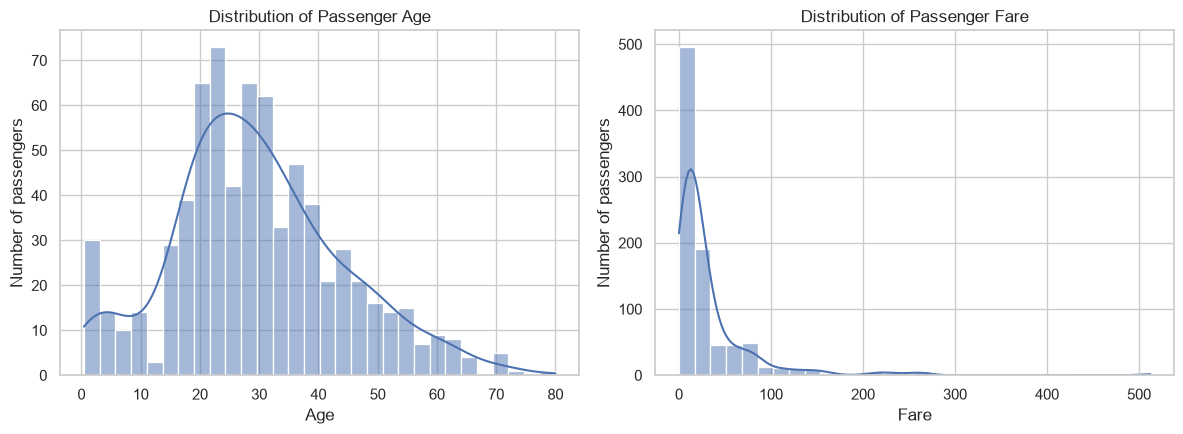

In [7]:
# TODO 5a: Histogram age & fare

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Passenger Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of passengers")

sns.histplot(
    data=df,
    x="fare",
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Distribution of Passenger Fare")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Number of passengers")

plt.tight_layout()
plt.show()

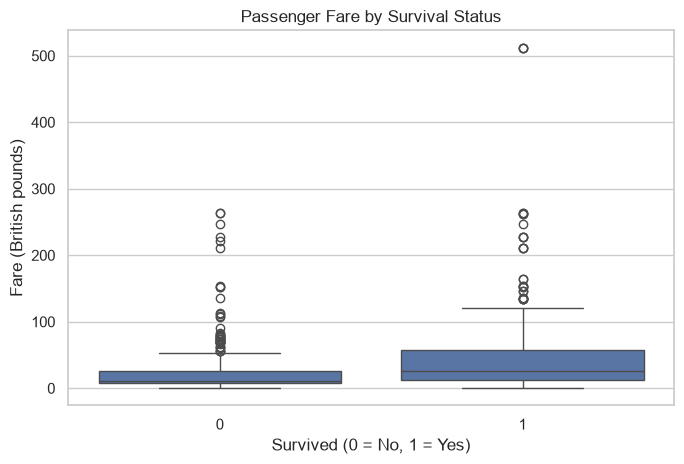

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass

fig, ax = plt.subplots(figsize=(7, 4.8))

sns.boxplot(
    data=df,
    x="survived",
    y="fare",
    ax=ax
)

ax.set_title("Passenger Fare by Survival Status")
ax.set_xlabel("Survived (0 = No, 1 = Yes)")
ax.set_ylabel("Fare (British pounds)")

plt.tight_layout()
plt.show()

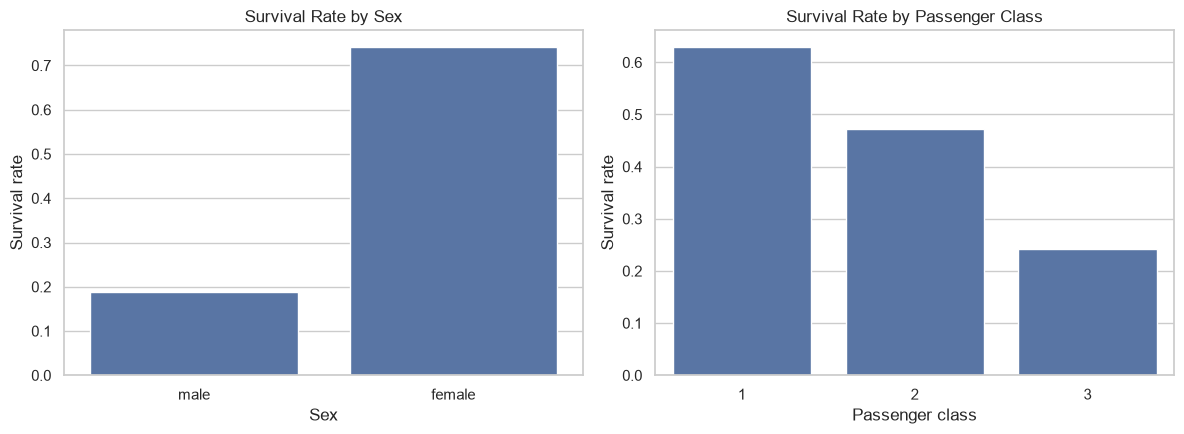

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(
    data=df,
    x="sex",
    y="survived",
    errorbar=None,
    ax=axes[0]
)

axes[0].set_title("Survival Rate by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Survival rate")

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    errorbar=None,
    ax=axes[1]
)

axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("Survival rate")

plt.tight_layout()
plt.show()

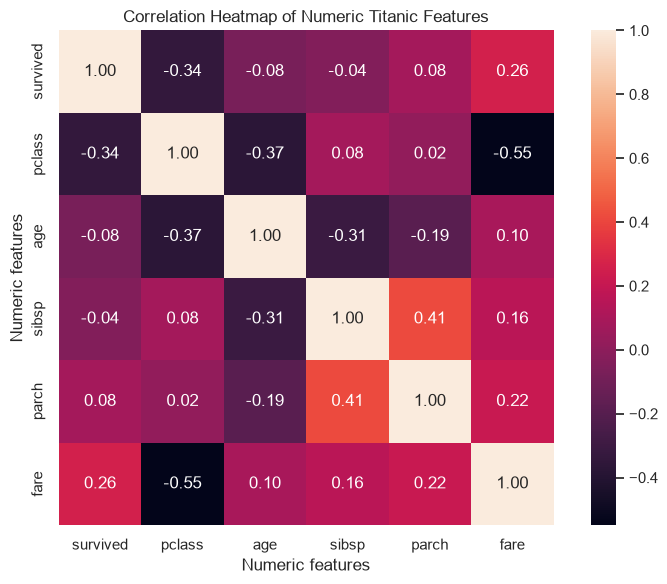

In [10]:
# TODO 5d: Heatmap correlation

numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    square=True,
    ax=ax
)

ax.set_title("Correlation Heatmap of Numeric Titanic Features")
ax.set_xlabel("Numeric features")
ax.set_ylabel("Numeric features")

plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Đồ thị histogram của hành khách theo tuổi và giá vé đều lệch phải, trong đó histogram về fare lệch rất rõ ràng trong khi của age thì tập trung ở độ tuổi thanh niên và trung niên.
- Boxplot: Nhóm sống sót có trung vị về fare cao hơn nhóm không sống sót; tuy nhiên, cả 2 nhóm đều có số lượng outliers khá nhiều.
- Bar survival: Dựa trên giới tính, phụ nữ có tỉ lệ sống sót cao hơn, khoảng hơn 400%, nó phản ánh khá giống trong các câu chuyện và phim khi phụ nữ và trẻ em được ưu tiên lên thuyền cứu nạn trước; dựa trên pclass thì hành khách thuộc class 1 có tỉ lệ sống sót cao nhất và giảm dàn từ class 1 đến class 3, trong đó tỉ lệ sống sót của class 3 chỉ khoảng 50% so với class 1.
- Heatmap: Từ heatmap ta thấy không có cặp biến nào có quan hệ mạnh với nhau cả. Cao nhất là pclass và fare với mức tương quan -0.55.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify

X = df.drop(columns=["survived"])
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.15 / 0.85, random_state=42, stratify=y_tmp)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

# In tỷ lệ survived từng tập
survival_ratio = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "val": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
})

survival_ratio

Train/Val/Test: (623, 8) (134, 8) (134, 8)


,train,val,test
survived,,,
0,0.616372,0.61194,0.619403
1,0.383628,0.38806,0.380597


**Nhận xét:**
- Tỷ lệ survived ở ba tập gần giống nhau, stratify giữ được phân phối target.

---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
        ("ord", "passthrough", ord_cols)
    ]
)

X_train_t = preprocess.fit_transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print("Transformed shapes:")
print("X_train_t:", X_train_t.shape)
print("X_val_t:", X_val_t.shape)
print("X_test_t:", X_test_t.shape)

Transformed shapes:
X_train_t: (623, 10)
X_val_t: (134, 10)
X_test_t: (134, 10)


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

- Pipeline chỉ được fit trên X_train để tránh data leakage vì khi fit, pipeline sẽ học các thông tin từ dữ liệu như median để fill missing, tham số scale của RobustScaler, và các category dùng cho OneHotEncoder.
- Nếu fit trên toàn bộ dataset trước khi chia hoặc fit cả validation và test, thì thông tin từ 2 bộ này đã bị dùng trong bước tiền xử lý.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
target_ratio = df["survived"].value_counts(normalize=True).sort_index()
print(target_ratio)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến mục tiêu `survived` có bị mất cân bằng. Cụ thể tỷ lệ survived là 38% còn not survived là 62%.
2. Nếu chỉ nhìn `Accuracy` thì có thể bị đánh lừa khi nếu mô hình luôn đoán là `survived = 1` thì accuracy = 0.62 nhưng không hữu ích trong thực tế.
3. Với bài toán này, mình sẽ ưu tiên `F1` vì metric này cân bằng so với Precision và Recall, cũng như không bị trường hợp như Accuracy bên trên.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Dựa trên heatmap ở task 5, đối với khả năng sống sót `survived`, đặc trưng tương quan dương mạnh nhất là `fare` với hệ số tương quan 0.26, còn hệ số tương quan âm mạnh nhất là `pclass` với hệ số -0.34. Cho thấy hành khách ở tầng lớp thượn lưu, mua vé giá cao thì khả năng sống sót càng cao. Tuy nhiên, cũng không tương quan mạnh lắm.
2. Cột thiếu nhiều nhất là `deck` thiếu tới 77% tổng dữ liệu, và nó không phải target nên được drop.
3. Biến mục tiêu có mất cân bằng, tỉ lệ sống sót survived=1 có tỷ lệ 62% còn survived=0 chiếm 38%.
4. Đặc trưng cần scaling là age, sibsp, parch, fare vì chúng có thang đó khác nhau; sex, embarked thì cần encoding vì chúng có giá trị dạng chữ, phải chuyển về số bằng One-Hot Encoding để sử dụng.
5. Điều thú vụ là tỷ lệ sống sót của nữ nhiều hơn nam và hành khách tầng lớp thượng lưu có tỷ lệ sống sót cao hơn. Điều này phản ánh có vẻ đúng thực tế và giống trong phim Titanic thật sự, khi phụ nữ và trẻ em được ưu tiên, và những ông tay to mặt lớn, có nhiều tiền và quyền cũng có thể giành chỗ hoặc lợi dụng quyền lực để được lên thuyền cứu sinh.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
